### Multi Agent System for insurance

In [1]:
from pdf2image import convert_from_path
import pytesseract
from PIL import Image

In [2]:
file = "/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/data/raw/images-to-pdf.pdf"
file2 = "/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/data/raw/phv01.pdf"

In [3]:
from insurance_multi_agent.text_extractor.text_extractor import TextExtractor

In [4]:
extractor = TextExtractor()
document = extractor.extract_text_from_pdf(file_path=file)
print(document)

Converting PDF to images...
Processing page 1...
Processing page 2...
source='/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/data/raw/images-to-pdf.pdf' content='AL LRexte™ Nan flexible Basisr - Ak ! " i nang\n\nPersénliche Daten |\n\nNil) I |\n\nVersicherungs-Nr. DN! 731960 i ii) Wil\nVersicherungsnehmer —(ssiti(‘i«s‘sSC( el Dem | il Mi) Ny " i Wit\nAGA HAI GAIL | |\nVersicherter Hi _ Axel Demel | Mal iN wi\nGeburtsdatum ra 07.11.1992 ||| | Lil Nh Mi\n\nas\n\niM {HO VeVITYOTYyOtOVHTT Pay enERetetenetet ry pepnesaetatetie terepnerpsrararasione rststaety\n\n== Versicherungs- und Altersrentenbeginn te A\n= Versicherungsbeginn 01.12.2020 (mittags 12:00 Uhr) E\n== Altersrentenbeginn 01.12.2059 SSS\n= Moderne flexible Basisrente (AR75) a E_\n: Anlageform fiir die Beitrage 0 % klassische Anlage SE\n100 % Fondsanlage ae\nBeitragszahlungsdauer 39 Jahre BEES a\nEnde der Beitragszahlungsdauer 01.12.2059 SS\nAufschubzeit bis zum Rentenbeginn 39 Jahre SS\nRentengarantieze

## Test Entity Extractor Agent

In [6]:
from insurance_multi_agent.agents.entity_extractor_agent import EntityExtractorAgent

In [8]:
# Extract entities from the document
entity_extractor = EntityExtractorAgent()
entities = entity_extractor.extract_entities(document)
print(entities)

policy_number='7731960' policy_type='Moderne flexible Basisrente (AR75)' insured_name='Axel Demel' insurer='ALTE LEIPZIGER Lebensversicherung auf Gegenseitigkeit' coverage_amount=500.0 premium=1500.0 start_date='01.12.2020' end_date='01.12.2059'


/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=InsuranceEntities(policy_..., end_date='01.12.2059'), input_type=InsuranceEntities])
  return self.__pydantic_serializer__.to_python(


In [9]:
# Inspect individual fields
print(f"Policy Number: {entities.policy_number}")
print(f"Insured Name: {entities.insured_name}")
print(f"Coverage Amount: {entities.coverage_amount}")
print(f"Start Date: {entities.start_date}")
print(f"End Date: {entities.end_date}")

Policy Number: 7731960
Insured Name: Axel Demel
Coverage Amount: 500.0
Start Date: 01.12.2020
End Date: 01.12.2059


## Test Risk Analyzer Agent

In [10]:
from insurance_multi_agent.agents.risk_analyzer_agent import RiskAnalyzerAgent

In [11]:
# Create risk analyzer with reliable model
risk_analyzer = RiskAnalyzerAgent()

In [12]:
# Analyze risks from the document
risks = risk_analyzer.analyze_risk(document)
print(risks)

content='1. Missing information related to detailed coverage clauses and specific definitions of benefits.\n2. Inconsistencies in the nomenclature used for \'Versicherungs-Nr.\' that appears multiple times with different formats.\n3. Lack of clarity regarding the “Wertzuwachs” and “Rentenzuwachs” before and after retirement, as it is not specified how these amounts are computed.\n4. Unusual clauses regarding the potential for changes in the rentenfaktor based on "Änderung der Rechnungsgrundlagen."\n5. Fraud risk due to unclear or vague sections that could lead to misinterpretation or exploitation of benefits.\n6. Ambiguity around the details for the payout of the Todesfallleistung, specifically how it may differ before and after the Altersrentenbeginn.\n7. Potential confusion on the terms regarding "Beitragsbefreiung" and its implications during the Berufsunfähigkeitsaustritt.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 188, 'prompt_toke

/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Risks(risks=['Potential f... performance' clause."]), input_type=Risks])
  return self.__pydantic_serializer__.to_python(


In [13]:
# Print individual risks
print(f"\nFound {len(risks.risks)} risks:\n")
for i, risk in enumerate(risks.risks, 1):
    print(f"{i}. {risk}")


Found 7 risks:

1. Potential for data inaccuracies due to fragmented or unclear information (e.g., names, dates, monetary figures)
2. Missing information regarding the exact terms of the death benefits, specifically during and after the guaranteed payout period
3. Inconsistencies in benefit descriptions (e.g., lifetime pension with no guaranteed monthly amount)
4. Absence of clear definitions for terms like 'Rentenfaktor' and implications of changing parameters affecting benefit amounts
5. Risk of misunderstanding related to the classifications of professions and their impact on insurance benefits (e.g., professions designated as 'Student','Angestrebter Grad')
6. Unusual clauses regarding the conditions of payout during the guarantee and non-guarantee periods without adequate explanation
7. Ambiguity in the description of survivor benefits, particularly the 'no performance' clause.


In [14]:
# Debug: Check what the LLM actually returned
print(f"Document clean_content length: {len(document.clean_content)}")
print(f"First 200 chars: {document.clean_content[:200]}")

# Try calling the LLM directly to see the raw response
from langchain_core.messages import HumanMessage, SystemMessage
messages = [
    SystemMessage(content=risk_analyzer.system_prompt),
    HumanMessage(content=document.clean_content)
]

print("\n--- Testing direct LLM call ---")
raw_response = risk_analyzer.llm.invoke(messages)
print(f"Raw response type: {type(raw_response)}")
print(f"Raw response: {raw_response.content[:500] if hasattr(raw_response, 'content') else raw_response}")

Document clean_content length: 4348
First 200 chars: AL LRexte™ Nan flexible Basisr - Ak ! " i nang
Persénliche Daten |
Nil) I |
Versicherungs-Nr. DN! 731960 i ii) Wil
Versicherungsnehmer —(ssiti(‘i«s‘sSC( el Dem | il Mi) Ny " i Wit
AGA HAI GAIL | |
Ver

--- Testing direct LLM call ---
Raw response type: <class 'langchain_core.messages.ai.AIMessage'>
Raw response: 1. Missing information - The document contains incomplete personal data sections, particularly regarding the columns without specific entries for items like the insurance number, insured person’s personal information, and recipient details.
2. Inconsistencies in the document - There are various typographical errors and misspellings throughout the document (e.g., "Berufsunfihigkeits-Zusatzve ‘ersic icherung," "Berufsunfihigkeit") which might suggest a lack of attention to detail.
3. Unusual claus


In [15]:
risks.risks

['Potential for data inaccuracies due to fragmented or unclear information (e.g., names, dates, monetary figures)',
 'Missing information regarding the exact terms of the death benefits, specifically during and after the guaranteed payout period',
 'Inconsistencies in benefit descriptions (e.g., lifetime pension with no guaranteed monthly amount)',
 "Absence of clear definitions for terms like 'Rentenfaktor' and implications of changing parameters affecting benefit amounts",
 "Risk of misunderstanding related to the classifications of professions and their impact on insurance benefits (e.g., professions designated as 'Student','Angestrebter Grad')",
 'Unusual clauses regarding the conditions of payout during the guarantee and non-guarantee periods without adequate explanation',
 "Ambiguity in the description of survivor benefits, particularly the 'no performance' clause."]

## Test Summary Agent

In [16]:
from insurance_multi_agent.agents.summary_agent import SummaryAgent

In [17]:
# Create summary agent
summary_agent = SummaryAgent()

In [18]:
# Generate summary from extracted entities and identified risks
summary = summary_agent.summarize(risks=risks, entities=entities)
print(summary)

content="This insurance document pertains to a policy with the following key details:\n\n- **Policy Number**: 7731960\n- **Policy Type**: Moderne flexible Basisrente (AR75)\n- **Insured Name**: Axel Demel\n- **Insurer**: ALTE LEIPZIGER Lebensversicherung auf Gegenseitigkeit\n- **Coverage Amount**: 500.0\n- **Premium**: 1500.0\n- **Start Date**: December 1, 2020\n- **End Date**: December 1, 2059\n\nIdentified risks in the policy include:\n\n1. Potential inaccuracies in data due to incomplete or unclear information.\n2. Lack of detailed information on the terms of death benefits, particularly regarding guaranteed payout periods.\n3. Confusing descriptions of benefits, such as lifetime pensions without guaranteed monthly amounts.\n4. Undefined terms, like 'Rentenfaktor,' which may affect understanding of benefit calculations.\n5. Possible misunderstandings related to job classifications that could impact insurance benefits.\n6. Unusual clauses regarding payout conditions that lack suffici

In [19]:
# Print just the content if it's an AIMessage object
if hasattr(summary, 'content'):
    print("\n=== FORMATTED SUMMARY ===\n")
    print(summary.content)
else:
    print("\n=== SUMMARY ===\n")
    print(summary)


=== FORMATTED SUMMARY ===

This insurance document pertains to a policy with the following key details:

- **Policy Number**: 7731960
- **Policy Type**: Moderne flexible Basisrente (AR75)
- **Insured Name**: Axel Demel
- **Insurer**: ALTE LEIPZIGER Lebensversicherung auf Gegenseitigkeit
- **Coverage Amount**: 500.0
- **Premium**: 1500.0
- **Start Date**: December 1, 2020
- **End Date**: December 1, 2059

Identified risks in the policy include:

1. Potential inaccuracies in data due to incomplete or unclear information.
2. Lack of detailed information on the terms of death benefits, particularly regarding guaranteed payout periods.
3. Confusing descriptions of benefits, such as lifetime pensions without guaranteed monthly amounts.
4. Undefined terms, like 'Rentenfaktor,' which may affect understanding of benefit calculations.
5. Possible misunderstandings related to job classifications that could impact insurance benefits.
6. Unusual clauses regarding payout conditions that lack suffic

In [20]:
text_extractor2 = TextExtractor()
document2 = text_extractor2.extract_text_from_pdf(file_path=file2)
print(document2.clean_content)

Converting PDF to images...
Processing page 1...
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...
Processing page 6...
Processing page 7...
Processing page 8...
Processing page 9...
Processing page 10...
Versicherungsschein Versicherung
Versicherungsverem af Gegersstigeet (va
Ammerlander Versicherung VVaG 26655 Westerstede
Ansprechpariner.
156/000 153/20/WI/CITIPOST OL 1-264 1/999/00133 polio seran Versicherung
al 26655 osm
Dennis Glisenkamp Telefon: 04488-5295950
Im Bachgarten 36 Telefax: 04488-5295959
50259 Pulheim E-Mail: info @ ammeraende-verschenung. de
Versicherungsschein-Nr.: 1003496681 Westerstede, den 19.01 2017
(bitte stets angeben)
Daten zum Versicherungsschein
Es bestehen folgende, rechtlich selbstandige und voneinander unabhangige Versichenungsvertrage:
Vertrags-Nr. Beginn / Ablauf Vers-Summe Jahresnefiobemrag
Gewols 00.00 Le)
(1) Haftpflicht Economic
01.01.2016 / 01.01.2018 46,00 EUR
mitversichert: Sonja Strack
Summe Nettojahresbeitrage


In [22]:
entity_extractor2 = EntityExtractorAgent()
entities2 = entity_extractor2.extract_entities(document2)
print(entities2)

policy_number='1003496681' policy_type='Privathaftpflicht' insured_name='Sonja Strack, geb. 25.08.86' insurer='Ammerlander Versicherung VVaG' coverage_amount=7500000.0 premium=54.74 start_date='01.01.2016' end_date='01.01.2018'


/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=InsuranceEntities(policy_..., end_date='01.01.2018'), input_type=InsuranceEntities])
  return self.__pydantic_serializer__.to_python(


In [ ]:
risk_analyzer2 = RiskAnalyzerAgent()
risks2 = risk_analyzer2.analyze_risk(document2)
print(risks2)

content='1. Incomplete or missing policy details (e.g., specific clauses and exclusions not clearly mentioned).\n2. Complex wording and structure leading to potential misunderstandings or misinterpretations of coverage.\n3. Lack of clarity regarding the payment deadlines for premiums, which may lead to unintentional lapses in coverage.\n4. Self-deductibles could create issues for policyholders unable to meet them, potentially resulting in a lack of coverage at critical times.\n5. Exclusions on coverage for various activities and items (e.g., certain vehicles, animals, and responsibilities) that may catch the insured off guard.\n6. Unusual limitations on coverage amounts for environmental damage claims, creating a risk for policyholders unaware of these constraints.\n7. The potential for unauthorized or late payment penalties, leading to increased financial risk during claim processes.\n8. Complexity in understanding the obligations of the insured regarding third-party claims, which mig

/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Risks(risks=['Fraud risk:...could be problematic.']), input_type=Risks])
  return self.__pydantic_serializer__.to_python(


In [ ]:
summary_agent2 = SummaryAgent()
summary2 = summary_agent2.summarize(risks=risks2, entities=entities2)
print(summary2)

content='The insurance document pertains to a liability policy (Policy Number: 1003496681) held by Dennis Glisenkamp with the insurer Ammerlander Versicherung VVaG. The policy type is Haftpflicht Economic, offering a coverage amount of €7,500,000, with an annual premium of €54.74. The policy commenced on January 1, 2016, and concluded on January 1, 2018.\n\nKey risks identified include:\n\n- **Fraud Risk**: There is potential for misrepresentation of information due to unclear terms and amounts.\n- **Missing Information**: Some policy details, coverage limits, and exclusions are vague or not clearly stated.\n- **Inconsistencies**: The document may contain unclear language and typos, which can lead to misinterpretation of coverage.\n- **Unusual Clauses**: There are references to conditions under which coverage may be void if premiums are not paid on time.\n\nOverall, the document has several clarity issues that could affect understanding and interpretation of the policy.' additional_kwa

## Test Pipeline Graph

In [5]:
from insurance_multi_agent.pipeline import InsurancePipeline

pipeline = InsurancePipeline()

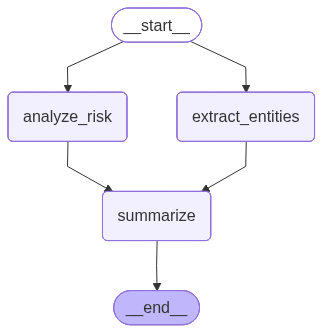

In [6]:
pipeline.display_pipeline()

## Run Pipeline

In [7]:
# Create initial state with the document we extracted earlier
initial_state = {
    "document": document,
    "entities": None,
    "risks": None,
    "summary": None
}

# Compile and run the pipeline
workflow = pipeline.graph.compile()
result = workflow.invoke(initial_state)

/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=InsuranceEntities(policy_..., end_date='01.12.2059'), input_type=InsuranceEntities])
  return self.__pydantic_serializer__.to_python(
/Users/rodrigo/Desktop/rodrigo_stuff/side_projects/Insurance-multi-agent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Risks(risks=["Missing inf...on for beneficiaries.']), input_type=Risks])
  return self.__pydantic_serializer__.to_python(


content='- Missing information (e.g., unclear personal information and formatting issues)\n- Inconsistencies in the document (e.g., mixed languages and irregular formatting)\n- Unusual clauses (e.g., no guaranteed monthly retirement pension in the chosen investment form)\n- Fraud risk (possible manipulation or misrepresentation due to unclear details and formatting)' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 1542, 'total_tokens': 1609, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0.0002715, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0002715, 'upstream_inference_prompt_cost': 0.0002313, 'upstream_inference_completions_cost': 4.02e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_

In [8]:
# Display results
print("Entities:")
print(result['entities'])
print("\nRisks:")
for risk in result['risks'].risks:
    print(f"  - {risk}")
print("\nSummary:")
print(result['summary'].content)

Entities:
policy_number='DN! 731960' policy_type='Moderne flexible Basisrente (AR75)' insured_name='Axel Demel' insurer='ALTE LEIPZIGER Lebensversicherung auf Gegenseitigkeit' coverage_amount=1500.0 premium=0.0 start_date='01.12.2020' end_date='01.12.2059'

Risks:
  - Missing information about the insured's occupation and income which are critical for assessing risk levels.
  - Inconsistencies in the document such as formatting issues, unclear terminology, and possible language errors that may lead to misinterpretation of terms and conditions.
  - Unusual clauses related to the guaranteed monthly pension not being specified, raising concerns over the clarity of the contract's benefits.
  - Potential lack of detail regarding the death benefit payouts before and after retirement and how they are calculated, which may cause confusion for beneficiaries.

Summary:
The insurance document is for a policy held by Axel Demel with ALTE LEIPZIGER Lebensversicherung auf Gegenseitigkeit, titled "Mo